<a href="https://colab.research.google.com/github/dallinhenrie/Hilton-Head-Light-Pollution/blob/main/Copy_of_HHI_Light_Pollution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scipy scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from google.colab import files
import io
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'font.family': 'monospace',
    'figure.dpi': 120
})

print('✅ Dependencies loaded successfully.')


✅ Dependencies loaded successfully.


In [ ]:
print('📂 Upload your LIGHT POLLUTION CSV file:')
uploaded_lp = files.upload()
lp_filename = list(uploaded_lp.keys())[0]
# Changed pd.read_csv to pd.read_excel to correctly handle .xlsx files
df_lp_raw = pd.read_excel(io.BytesIO(uploaded_lp[lp_filename]))
print(f'\n✅ Light pollution file loaded: "{lp_filename}"')
print(f'   Shape: {df_lp_raw.shape[0]} rows × {df_lp_raw.shape[1]} columns')
display(df_lp_raw.head())

📂 Upload your LIGHT POLLUTION CSV file:


Saving LIGHT POLUTION CVS.xlsx to LIGHT POLUTION CVS (1).xlsx

✅ Light pollution file loaded: "LIGHT POLUTION CVS (1).xlsx"
   Shape: 7 rows × 2 columns


,year,mean_radiance
0,2018,1.611
1,2019,1.591
2,2020,1.663
3,2021,1.670
4,2022,1.691


In [ ]:
print('📂 Upload your POPULATION CSV file:')
uploaded_pop = files.upload()
pop_filename = list(uploaded_pop.keys())[0]
df_pop_raw = pd.read_excel(io.BytesIO(uploaded_pop[pop_filename]))
print(f'\n✅ Population file loaded: "{pop_filename}"')
print(f'   Shape: {df_pop_raw.shape[0]} rows × {df_pop_raw.shape[1]} columns')
display(df_pop_raw.head())


📂 Upload your POPULATION CSV file:


Saving HHI Population Data.xlsx to HHI Population Data (2).xlsx

✅ Population file loaded: "HHI Population Data (2).xlsx"
   Shape: 21 rows × 3 columns


,Unnamed: 0,YEAR,POPU.
0,NaN,1960,300
1,NaN,1980,11344
2,NaN,1990,23694
3,NaN,2000,33862
4,NaN,2010,37219


In [ ]:
print('=' * 60)
print('  COLUMN CONFIGURATION')
print('=' * 60)
print('Select the correct columns from your uploaded files.\n')

lp_year_sel = widgets.Dropdown(
    options=df_lp_raw.columns.tolist(),
    description='LP → Year:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='400px')
)
lp_val_sel = widgets.Dropdown(
    options=df_lp_raw.columns.tolist(),
    description='LP → Value:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='400px')
)
pop_year_sel = widgets.Dropdown(
    options=df_pop_raw.columns.tolist(),
    description='Pop → Year:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='400px')
)
pop_val_sel = widgets.Dropdown(
    options=df_pop_raw.columns.tolist(),
    description='Pop → Value:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='400px')
)

def try_select(dropdown, keywords):
    for kw in keywords:
        matches = [c for c in dropdown.options if kw.lower() in c.lower()]
        if matches:
            dropdown.value = matches[0]
            return

try_select(lp_year_sel, ['year', 'yr', 'date'])
try_select(lp_val_sel, ['radiance', 'brightness', 'pollution', 'sqm', 'light', 'lp', 'value', 'mag'])
try_select(pop_year_sel, ['year', 'yr', 'date'])
try_select(pop_val_sel, ['population', 'pop', 'count', 'people', 'inhabitants', 'value'])

display(widgets.HTML('<b>── Light Pollution File ──</b>'))
display(lp_year_sel, lp_val_sel)
display(widgets.HTML('<br><b>── Population File ──</b>'))
display(pop_year_sel, pop_val_sel)
print('\n⬆️  Adjust dropdowns above, then run the next cell.')


  COLUMN CONFIGURATION
Select the correct columns from your uploaded files.



HTML(value='<b>── Light Pollution File ──</b>')

Dropdown(description='LP → Year:', layout=Layout(width='400px'), options=('year', 'mean_radiance'), style=Desc…

Dropdown(description='LP → Value:', index=1, layout=Layout(width='400px'), options=('year', 'mean_radiance'), …

HTML(value='<br><b>── Population File ──</b>')

Dropdown(description='Pop → Year:', index=1, layout=Layout(width='400px'), options=('Unnamed: 0', 'YEAR', 'POP…

Dropdown(description='Pop → Value:', index=2, layout=Layout(width='400px'), options=('Unnamed: 0', 'YEAR', 'PO…


⬆️  Adjust dropdowns above, then run the next cell.


In [ ]:
LP_YEAR  = lp_year_sel.value
LP_VAL   = lp_val_sel.value
POP_YEAR = pop_year_sel.value
POP_VAL  = pop_val_sel.value

print(f'Using columns:')
print(f'  Light Pollution  → year: "{LP_YEAR}", value: "{LP_VAL}"')
print(f'  Population       → year: "{POP_YEAR}", value: "{POP_VAL}"')

df_lp  = df_lp_raw[[LP_YEAR, LP_VAL]].rename(columns={LP_YEAR: 'year', LP_VAL: 'light_pollution'})
df_pop = df_pop_raw[[POP_YEAR, POP_VAL]].rename(columns={POP_YEAR: 'year', POP_VAL: 'population'})

df_lp['year']             = pd.to_numeric(df_lp['year'], errors='coerce')
df_lp['light_pollution']  = pd.to_numeric(df_lp['light_pollution'], errors='coerce')
df_pop['year']            = pd.to_numeric(df_pop['year'], errors='coerce')
df_pop['population']      = pd.to_numeric(df_pop['population'], errors='coerce')

df_lp.dropna(inplace=True)
df_pop.dropna(inplace=True)

df_lp  = df_lp.groupby('year', as_index=False).mean()
df_pop = df_pop.groupby('year', as_index=False).mean()

df = pd.merge(df_lp, df_pop, on='year').sort_values('year').reset_index(drop=True)

if df.empty:
    print('\n❌ ERROR: No matching years found between the two files.')
else:
    print(f'\n✅ Merged dataset: {len(df)} years of data ({int(df.year.min())}–{int(df.year.max())})')
    display(df)


Using columns:
  Light Pollution  → year: "year", value: "mean_radiance"
  Population       → year: "YEAR", value: "POPU."

✅ Merged dataset: 7 years of data (2018–2024)


,year,light_pollution,population
0,2018,1.611,39935.0
1,2019,1.591,39981.0
2,2020,1.663,37586.0
3,2021,1.670,37662.0
4,2022,1.691,38035.0
5,2023,1.785,38163.0
6,2024,1.911,38158.0


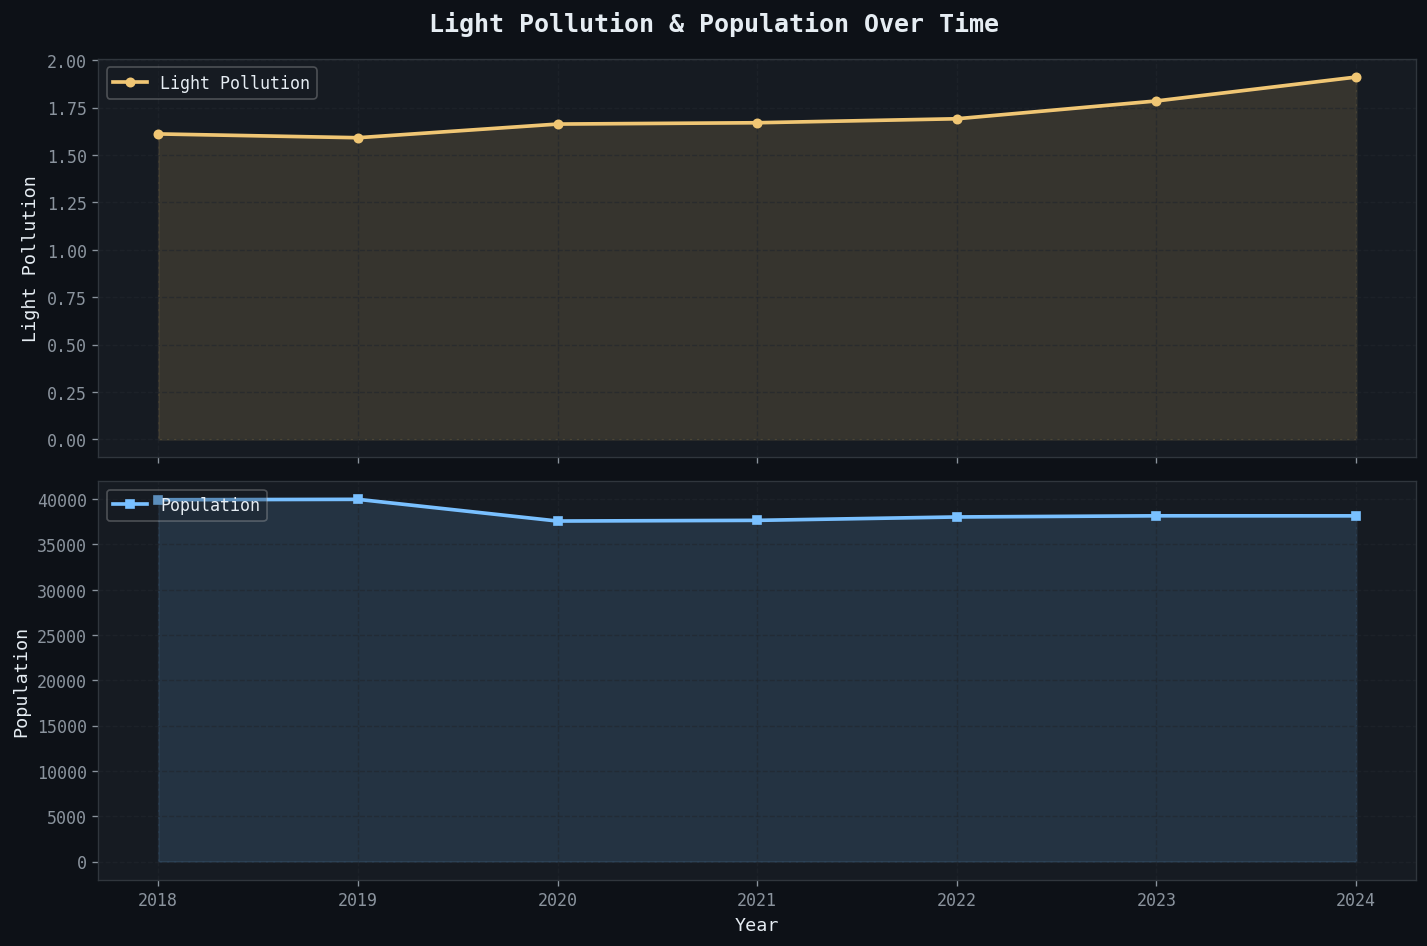

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Light Pollution & Population Over Time', fontsize=15, fontweight='bold',
             color='#e6edf3', y=0.98)

ax1 = axes[0]
ax1.plot(df['year'], df['light_pollution'], color='#f0c674', linewidth=2.2,
         marker='o', markersize=5, label='Light Pollution')
ax1.fill_between(df['year'], df['light_pollution'], alpha=0.15, color='#f0c674')
ax1.set_ylabel('Light Pollution', fontsize=11)
ax1.legend(loc='upper left', framealpha=0.3)
ax1.grid(True)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

ax2 = axes[1]
ax2.plot(df['year'], df['population'], color='#79c0ff', linewidth=2.2,
         marker='s', markersize=5, label='Population')
ax2.fill_between(df['year'], df['population'], alpha=0.15, color='#79c0ff')
ax2.set_ylabel('Population', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.legend(loc='upper left', framealpha=0.3)
ax2.grid(True)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('time_series.png', bbox_inches='tight', dpi=150)
plt.show()


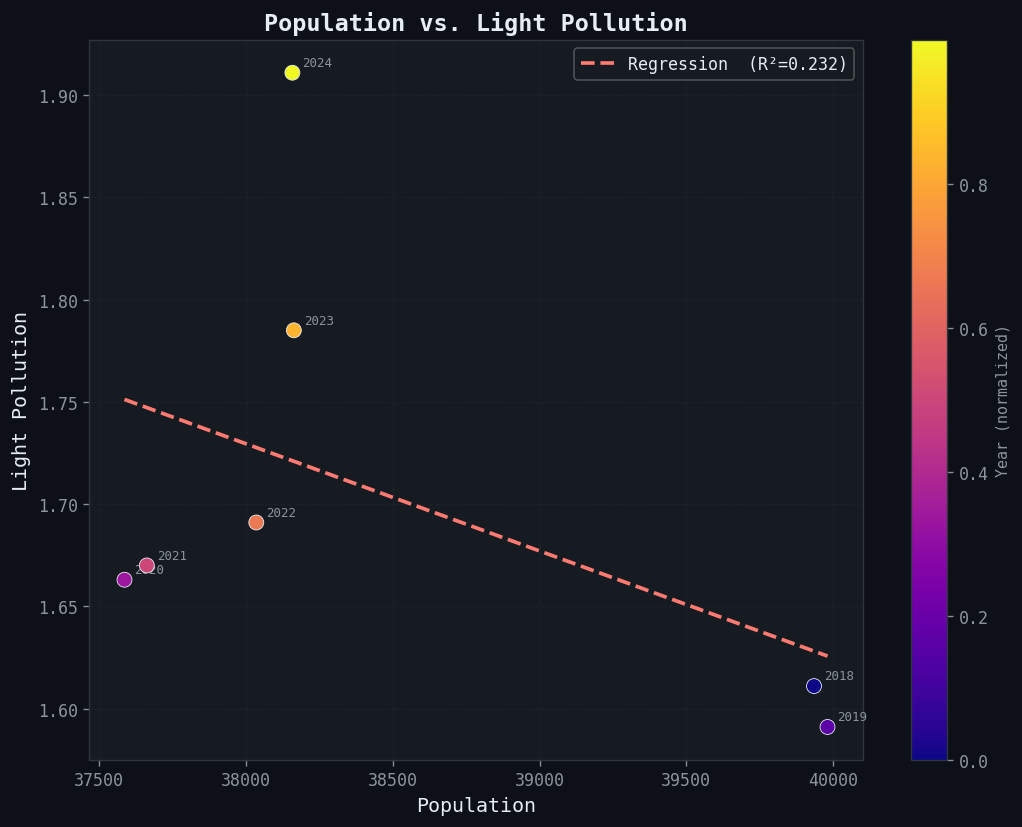

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

x = df['population'].values
y = df['light_pollution'].values

years_norm = (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min() + 1e-9)
scatter = ax.scatter(x, y, c=years_norm, cmap='plasma', s=80, zorder=5,
                     edgecolors='#e6edf3', linewidths=0.5)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='#ff7b72', linewidth=2.2, linestyle='--',
        label=f'Regression  (R²={r_value**2:.3f})', zorder=4)

for _, row in df.iterrows():
    ax.annotate(str(int(row['year'])),
                (row['population'], row['light_pollution']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7.5, color='#8b949e')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year (normalized)', fontsize=9, color='#8b949e')

ax.set_xlabel('Population', fontsize=12)
ax.set_ylabel('Light Pollution', fontsize=12)
ax.set_title('Population vs. Light Pollution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.3)
ax.grid(True)

plt.tight_layout()
plt.savefig('scatter_regression.png', bbox_inches='tight', dpi=150)
plt.show()


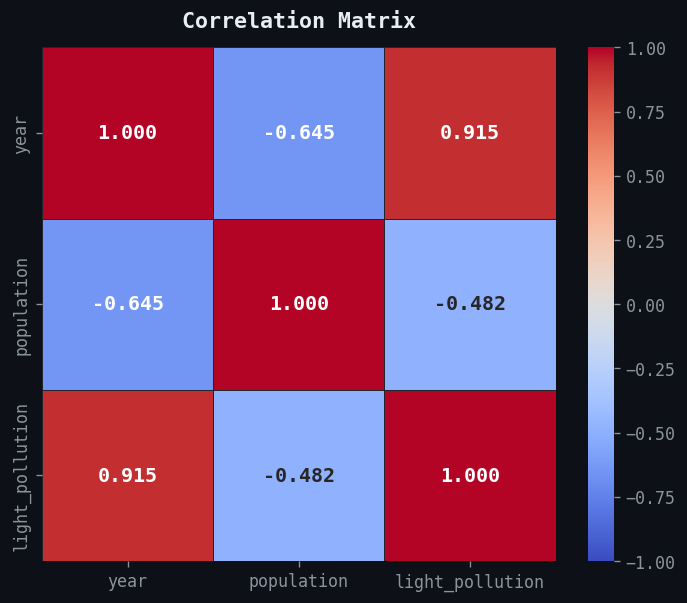

In [ ]:
corr_matrix = df[['year', 'population', 'light_pollution']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    linecolor='#21262d',
    annot_kws={'size': 12, 'weight': 'bold'},
    square=True
)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


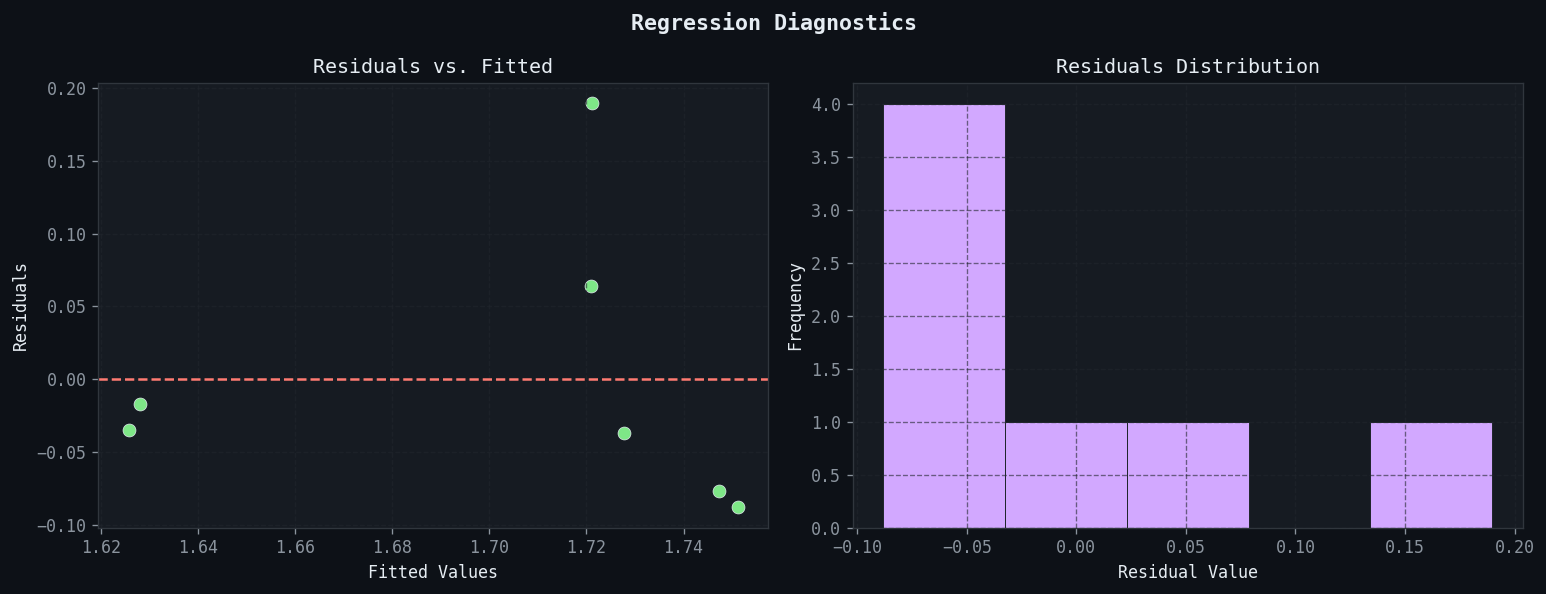

In [ ]:
y_pred = slope * df['population'].values + intercept
residuals = df['light_pollution'].values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Regression Diagnostics', fontsize=13, fontweight='bold')

axes[0].scatter(y_pred, residuals, color='#7ee787', s=60,
                edgecolors='#e6edf3', linewidths=0.4)
axes[0].axhline(0, color='#ff7b72', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')
axes[0].grid(True)

axes[1].hist(residuals, bins=max(5, len(residuals)//3), color='#d2a8ff',
             edgecolor='#21262d', linewidth=0.6)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
pearson_r, p_val   = stats.pearsonr(df['population'], df['light_pollution'])
spearman_r, sp_val = stats.spearmanr(df['population'], df['light_pollution'])
r_squared          = r_value ** 2

std_pop = df['population'].std()
std_lp  = df['light_pollution'].std()
beta    = slope * (std_pop / std_lp) if std_lp > 0 else 0

confidence = max(0.0, 1.0 - p_val)
PES = pearson_r * r_squared * confidence * 100
PES = max(-100, min(100, PES))

def interpret_pes(score):
    a = abs(score)
    direction = 'POSITIVE' if score > 0 else 'NEGATIVE' if score < 0 else 'NEUTRAL'
    if   a >= 70: strength = 'Very Strong'
    elif a >= 45: strength = 'Strong'
    elif a >= 25: strength = 'Moderate'
    elif a >= 10: strength = 'Weak'
    else:         strength = 'Negligible'
    return direction, strength

direction, strength = interpret_pes(PES)

def sig_label(p):
    if p < 0.001: return '*** (p < 0.001)'
    elif p < 0.01: return '** (p < 0.01)'
    elif p < 0.05: return '* (p < 0.05)'
    else: return f'ns (p = {p:.3f})'

sep  = '═' * 62
thin = '─' * 62

print(f'\n{sep}')
print(f'  📊  LIGHT POLLUTION — POPULATION ANALYSIS REPORT')
print(sep)
print(f'  Dataset            : {len(df)} years  ({int(df.year.min())}–{int(df.year.max())})')
print(thin)
print(f'  CORRELATION METRICS')
print(thin)
print(f'  Pearson r          : {pearson_r:+.4f}   {sig_label(p_val)}')
print(f'  Spearman ρ         : {spearman_r:+.4f}   {sig_label(sp_val)}')
print(f'  R² (var. explained): {r_squared:.4f}  ({r_squared*100:.1f}% of LP variance explained)')
print(thin)
print(f'  REGRESSION COEFFICIENTS')
print(thin)
print(f'  Slope (raw)        : {slope:+.6e}  (LP units per person)')
print(f'  Standardized β     : {beta:+.4f}  (std-dev LP per std-dev pop)')
print(f'  Intercept          : {intercept:+.4f}')
print(f'  Std Error          : {std_err:.6e}')
print(thin)
print(f'  ╔══════════════════════════════════════════════════╗')
print(f'  ║  POPULATION EFFECT SCORE (PES)                  ║')
print(f'  ║                                                  ║')
print(f'  ║   PES = {PES:+.2f} / 100                          ║')
print(f'  ║   {strength} {direction} Effect              ║')
print(f'  ╚══════════════════════════════════════════════════╝')
print(thin)
if abs(PES) < 10:
    print(f'  Population has negligible influence on light pollution.')
elif PES > 0:
    print(f'  Higher population → GREATER light pollution.')
    print(f'  {strength} positive relationship (PES={PES:+.1f}).')
    print(f'  Population explains {r_squared*100:.1f}% of LP variation.')
    if p_val > 0.05:
        print(f'  ⚠️  Not statistically significant (p={p_val:.3f}). Collect more data.')
else:
    print(f'  Higher population → LOWER light pollution.')
    print(f'  {strength} negative relationship (PES={PES:+.1f}).')
    if p_val > 0.05:
        print(f'  ⚠️  Not statistically significant (p={p_val:.3f}).')
print(sep)
print(f'  Per-person effect: light pollution changes by {slope:+.3e} units per person.')
print(sep + '\n')



══════════════════════════════════════════════════════════════
  📊  LIGHT POLLUTION — POPULATION ANALYSIS REPORT
══════════════════════════════════════════════════════════════
  Dataset            : 7 years  (2018–2024)
──────────────────────────────────────────────────────────────
  CORRELATION METRICS
──────────────────────────────────────────────────────────────
  Pearson r          : -0.4817   ns (p = 0.274)
  Spearman ρ         : -0.3214   ns (p = 0.482)
  R² (var. explained): 0.2320  (23.2% of LP variance explained)
──────────────────────────────────────────────────────────────
  REGRESSION COEFFICIENTS
──────────────────────────────────────────────────────────────
  Slope (raw)        : -5.240896e-05  (LP units per person)
  Standardized β     : -0.4817  (std-dev LP per std-dev pop)
  Intercept          : +3.7210
  Std Error          : 4.263960e-05
──────────────────────────────────────────────────────────────
  ╔══════════════════════════════════════════════════╗
  ║  POPULATI

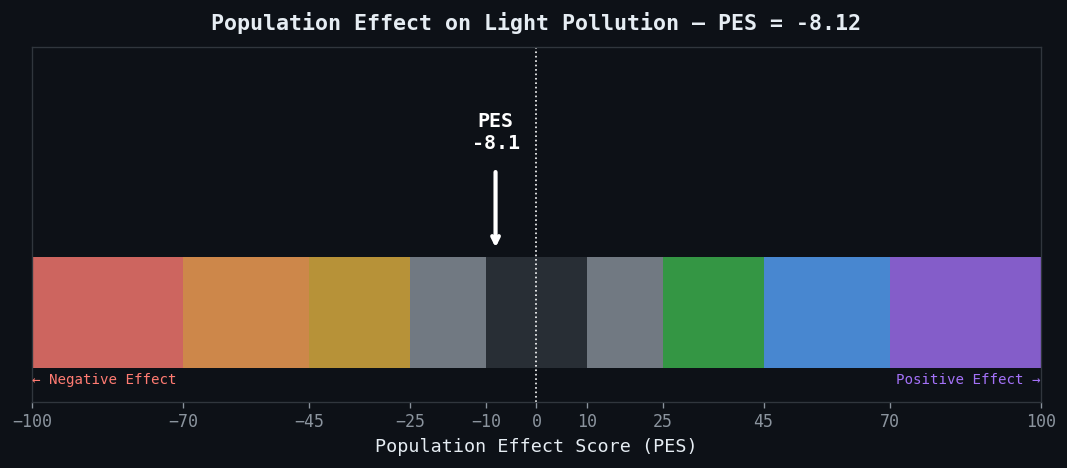

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

segments = [
    (-100, -70, '#ff7b72', 'Very Strong Negative'),
    (-70,  -45, '#ffa657', 'Strong Negative'),
    (-45,  -25, '#e3b341', 'Moderate Negative'),
    (-25,  -10, '#8b949e', 'Weak Negative'),
    (-10,   10, '#30363d', 'Negligible'),
    ( 10,   25, '#8b949e', 'Weak Positive'),
    ( 25,   45, '#3fb950', 'Moderate Positive'),
    ( 45,   70, '#58a6ff', 'Strong Positive'),
    ( 70,  100, '#a371f7', 'Very Strong Positive'),
]

for (start, end, color, label) in segments:
    ax.barh(0, end - start, left=start, height=0.5, color=color, alpha=0.8)

ax.annotate('', xy=(PES, 0.28), xytext=(PES, 0.65),
            arrowprops=dict(arrowstyle='->', color='white', lw=2.5))
ax.text(PES, 0.72, f'PES\n{PES:+.1f}', ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='white')

ax.set_xlim(-100, 100)
ax.set_ylim(-0.4, 1.2)
ax.set_yticks([])
ax.set_xticks([-100, -70, -45, -25, -10, 0, 10, 25, 45, 70, 100])
ax.axvline(0, color='white', linewidth=1.0, linestyle=':')
ax.set_xlabel('Population Effect Score (PES)', fontsize=11)
ax.set_title(f'Population Effect on Light Pollution — PES = {PES:+.2f}',
             fontsize=13, fontweight='bold', color='#e6edf3', pad=10)
ax.text(-100, -0.32, '← Negative Effect', fontsize=8.5, color='#ff7b72')
ax.text( 100, -0.32, 'Positive Effect →', fontsize=8.5, color='#a371f7', ha='right')

plt.tight_layout()
plt.savefig('pes_gauge.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
summary = pd.DataFrame({
    'Metric': [
        'Years of Data', 'Year Range',
        'Pearson r', 'Pearson p-value',
        'Spearman rho', 'Spearman p-value',
        'R-squared', 'Regression Slope (raw)',
        'Standardized Beta', 'Intercept',
        'Standard Error', 'POPULATION EFFECT SCORE (PES)',
        'Effect Direction', 'Effect Strength'
    ],
    'Value': [
        len(df), f"{int(df.year.min())}–{int(df.year.max())}",
        round(pearson_r, 6), round(p_val, 6),
        round(spearman_r, 6), round(sp_val, 6),
        round(r_squared, 6), f"{slope:.6e}",
        round(beta, 6), round(intercept, 6),
        f"{std_err:.6e}", round(PES, 4),
        direction, strength
    ]
})

summary.to_csv('analysis_summary.csv', index=False)
df.to_csv('merged_data.csv', index=False)
display(summary)

for fname in ['analysis_summary.csv', 'merged_data.csv',
              'time_series.png', 'scatter_regression.png',
              'correlation_heatmap.png', 'residuals.png', 'pes_gauge.png']:
    try:
        files.download(fname)
    except Exception as e:
        print(f'  (Could not auto-download {fname}: {e})')

print('\n🎉 Analysis complete!')


,Metric,Value
0,Years of Data,7
1,Year Range,2018–2024
2,Pearson r,-0.481701
3,Pearson p-value,0.273713
4,Spearman rho,-0.321429
5,Spearman p-value,0.482072
6,R-squared,0.232036
7,Regression Slope (raw),-5.240896e-05
8,Standardized Beta,-0.481701
9,Intercept,3.721038


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Analysis complete!
